In [ ]:
import pandas as pd
path = "Your/data"

In [2]:
!jupyter nbconvert your_notebook.ipynb --ClearMetadataPreprocessor.enabled=True --ClearOutputPreprocessor.enabled=True --inplace

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.


In [ ]:
!pip install serpapi

In [ ]:
from serpapi import search

params = {
  "api_key": "YOUR_API_KEY",
  "engine": "google_maps_reviews",
  "hl": "en",
  "place_id": "ChIJn8k41_f5wIcRSEEczaxXS9M"
}
res = []
for x in range(20):
  print(x)
  results = search(params)
  if "error" in results:
    print(results["error"])
    break
  next_page_token  = results["serpapi_pagination"]["next_page_token"]
  res.append(results)
  params["next_page_token"] = next_page_token
reviews = []
for x in res:
  reviews.append(pd.DataFrame(x["reviews"]))
reviews = pd.concat(reviews)

reviews.to_csv(path+'/reviews.csv')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [ ]:
from nltk.stem.snowball import stopwords
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

import re

dataset = reviews['snippet'].to_list()

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

word_counts = {}

for sentence in dataset:
    words = nltk.word_tokenize(sentence)
    for word in words:
        if word not in word_counts:
            word_counts[word] = 1
        else:
            word_counts[word] += 1
stop_words = set(stopwords.words('english'))
for word in list(word_counts.keys()):
    if word in stop_words:
        del word_counts[word]

word_counts_df = pd.DataFrame.from_dict(word_counts, orient='index', columns=['count'])
word_counts_df.sort_values(by=['count'], ascending=False, inplace=True)
top_words = word_counts_df.head(10)
top_words

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,count
hospital,115
care,111
staff,82
nurses,67
nurse,66
surgery,61
experience,60
time,55
nkc,54
great,53


In [ ]:
words_in_reviews = []
for sentence in dataset:
  words = nltk.word_tokenize(sentence)
  sentence_vector = {}
  for top_word in top_words.index:
    if top_word in words:
      sentence_vector[top_word] = True
    else:
      sentence_vector[top_word] = False
  words_in_reviews.append(sentence_vector)
words_in_reviews_df = pd.DataFrame(words_in_reviews)
words_in_reviews_df

,hospital,care,staff,nurses,nurse,surgery,experience,time,nkc,great
0,True,True,True,True,False,False,True,True,True,False
1,True,True,False,False,True,True,True,False,True,False
2,True,True,False,True,True,False,True,False,False,False
3,False,False,True,False,False,True,False,False,False,True
4,True,False,True,True,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...
192,True,True,False,False,True,False,False,False,False,False
193,True,False,True,False,False,False,True,False,False,True
194,True,True,False,False,False,True,False,False,True,True
195,True,True,False,True,False,False,False,False,False,False


In [ ]:
reviews = pd.read_csv(path+'/reviews.csv')

In [ ]:
reviews.columns

Index(['Unnamed: 0', 'position', 'link', 'rating', 'date', 'iso_date',
       'iso_date_of_last_edit', 'source', 'review_id', 'user', 'snippet',
       'extracted_snippet', 'likes', 'response', 'images'],
      dtype='object')

In [ ]:
reviews.describe()

,Unnamed: 0,position,rating,likes
count,197.000000,197.000000,197.000000,197.000000
mean,4.436548,5.436548,4.131980,0.060914
std,2.853978,2.853978,1.447321,0.540545
min,0.000000,1.000000,1.000000,0.000000
25%,2.000000,3.000000,4.000000,0.000000
50%,4.000000,5.000000,5.000000,0.000000
75%,7.000000,8.000000,5.000000,0.000000
max,9.000000,10.000000,5.000000,7.000000


In [ ]:
reviews['snippet']

,snippet
0,My husband and I had an incredible experience ...
1,I had the most amazing experience having surge...
2,My experience at NKCH was amazing. My nurses a...
3,Great service from start to finish. Everybody ...
4,I had to stay here a little over a week/week a...
...,...
192,"I was admitted for 4 days, drugged up, told I ..."
193,Dr. Wayman! Amazing O.B. & so glad you brought...
194,My recent surgery at NKC Hospital didn't feel ...
195,I recently went to the emergency room at North...


In [ ]:
reviews['length'] = reviews['snippet'].apply(lambda x: len(x))

In [ ]:
import pandas as pd

# Combine the words_in_reviews_df with the rating column from the original reviews dataframe
reviews_with_words = pd.concat([reviews['rating'], words_in_reviews_df], axis=1)

# Filter for poor ratings (e.g., 1 or 2 stars)
poor_reviews_data = reviews_with_words[reviews_with_words['rating'] <= 2]

# Drop the 'rating' column to only have word presence flags
poor_reviews_word_presence = poor_reviews_data.drop(columns=['rating'])

# Sum the True values for each word to get their counts in poor reviews
poor_ratings_word_counts = poor_reviews_word_presence.sum().sort_values(ascending=False)

print("Top words found in poor ratings (1 or 2 stars):")
print(poor_ratings_word_counts)

Top words found in poor ratings (1 or 2 stars):
hospital      22
care          16
nurse         15
nkc           11
time           9
staff          7
surgery        7
nurses         7
experience     6
great          2
dtype: int64


In [ ]:
reviews['rating'].value_counts().sort_index(ascending=False)

,count
rating,
5.0,132
4.0,21
3.0,8
2.0,10
1.0,26


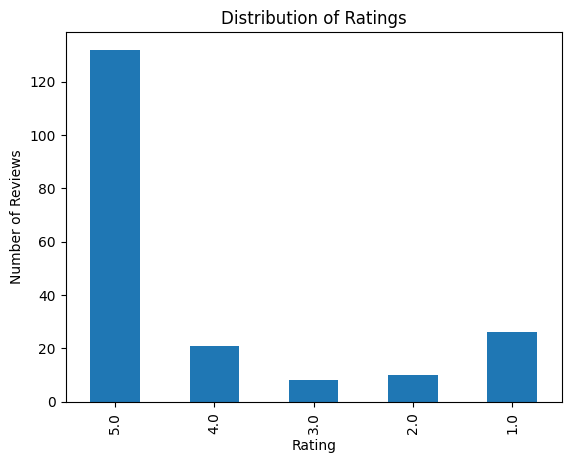

In [ ]:
import matplotlib.pyplot as plt

reviews['rating'].value_counts().sort_index(ascending=False).plot(kind='bar')

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
reviews['length'].describe()

,length
count,197.000000
mean,476.446701
std,389.520746
min,101.000000
25%,216.000000
50%,340.000000
75%,639.000000
max,2999.000000


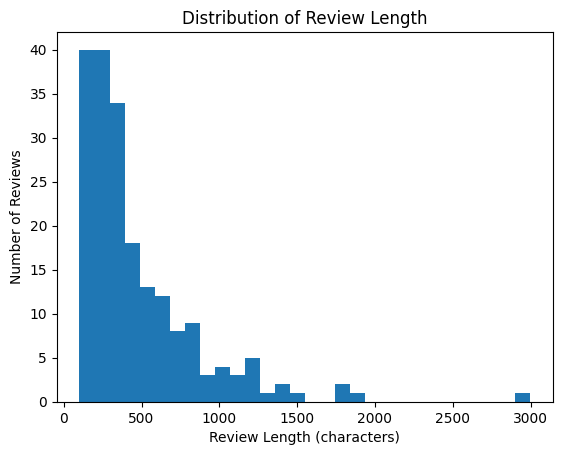

In [ ]:
import matplotlib.pyplot as plt

# Plot distribution of review length
reviews['length'].plot(kind='hist', bins=30)

plt.title('Distribution of Review Length')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
import pandas as pd
import spacy
import requests
from bs4 import BeautifulSoup
import re

# Check if the model is loaded, if not, try to download it
try:
    nlp = spacy.load("en_core_web_lg")
except OSError:
    print("SpaCy model 'en_core_web_lg' not found. Attempting to download it...")
    !python -m spacy download en_core_web_lg
    nlp = spacy.load("en_core_web_lg")

pd.set_option("display.max_rows", 200)

SpaCy model 'en_core_web_lg' not found. Attempting to download it...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Add ORG names to the model
orgs = ['Labor & Delivery', 'Maternal Child Health']

from spacy.pipeline import EntityRuler

# Check if 'entity_ruler' already exists in the pipeline
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp.get_pipe("entity_ruler")

# Define the patterns for business-specific departments
new_patterns = []
for org in orgs:
    new_patterns.append({"label": "ORG", "pattern": org})

# Add the patterns to the ruler
ruler.add_patterns(new_patterns)

In [ ]:
# Set your Google Drive path where the reviews file is stored
path = "Your/data"

# Load the reviews dataset
reviews = pd.read_csv("reviews.csv")

In [ ]:
from spacy import displacy
from spacy.tokens import Span

# Function to clean and fix entity recognition
def fix_entities(review, doc, valid_orgs):
    fixed_ents = []

    # Keep only correct ORG entities from the custom department list
    for ent in doc.ents:
        if ent.label_ == "ORG":
            if ent.text in valid_orgs:
                fixed_ents.append(ent)
        else:
            fixed_ents.append(ent)

    # Rule: find names that appear immediately before one of the valid ORG names
    # Example: Rachel Labor & Delivery
    pattern = r'([A-Z][a-z]+)\s+(Labor\s*&\s*Delivery|Maternal\s*Child\s*Health)'

    for match in re.finditer(pattern, review):
        person_name = match.group(1)

        # Find the exact character span of the person name
        start = match.start(1)
        end = match.end(1)

        person_span = doc.char_span(start, end, label="PERSON")

        if person_span is not None:
            fixed_ents.append(person_span)

    # Remove duplicates by using (text, label, start, end)
    unique_ents = []
    seen = set()

    for ent in fixed_ents:
        key = (ent.text, ent.label_, ent.start_char, ent.end_char)
        if key not in seen:
            seen.add(key)
            unique_ents.append(ent)

    # Sort entities by start position
    unique_ents = sorted(unique_ents, key=lambda x: x.start_char)

    return unique_ents

In [ ]:
people = []

# Show entity visualization for a few sample reviews
for review in reviews['snippet'].head(3):
    if type(review) != str:
        print('Error', review)
        continue

    # Clean text
    review = review.replace('(', ' ')
    review = review.replace(')', ' ')

    # Process review
    doc = nlp(review)

    # Fix entity labels - this function can return potentially overlapping spans
    fixed_ents = fix_entities(review, doc, orgs)

    # Filter out overlapping spans to satisfy spaCy's requirements for doc.ents
    # By default, filter_spans prioritizes longer spans over shorter, overlapping ones.
    filtered_ents = spacy.util.filter_spans(fixed_ents)

    # Replace doc entities with the cleaned and filtered ones for display
    doc.ents = filtered_ents

    # Show entity visualization
    displacy.render(doc, style="ent", jupyter=True)

    # Print entities
    for ent in doc.ents:
        print(ent.text, ent.label_)
        if ent.label_ == "PERSON":
            people.append(ent.text)

print(people)

Rachel PERSON
Labor & Delivery ORG
12/15–12/16 CARDINAL
Ashley PERSON
Labor & Delivery ORG
12/16 CARDINAL
Makayla   PERSON
Maternal Child Health ORG
12/16–12/18 CARDINAL
Jill   PERSON
Maternal Child Health ORG
12/17 DATE
Elizabeth   PERSON
Maternal Child Health ORG
12/18 DATE
first ORDINAL
Heizman PERSON


Megan PERSON
their busy day DATE
Megan PERSON
Werner PERSON
the years DATE
the day DATE


Jada PERSON
only 22 CARDINAL
5 days DATE
['Rachel', 'Ashley', 'Makayla  ', 'Jill  ', 'Elizabeth  ', 'Heizman', 'Megan', 'Megan', 'Werner', 'Jada']


In [ ]:
print(people)

['Rachel', 'Ashley', 'Makayla  ', 'Jill  ', 'Elizabeth  ', 'Heizman', 'Megan', 'Megan', 'Werner', 'Jada']


In [ ]:
# Create an empty list to store extracted entities
entities = []

# Loop through each review
for _, row in reviews.iterrows():
    review_id = row['review_id']
    review = row['snippet']

    # Skip if review is not text
    if type(review) != str:
        continue

    # Clean brackets to avoid parsing issues
    review = review.replace('(', ' ')
    review = review.replace(')', ' ')

    # Run spaCy NLP model on the review
    doc = nlp(review)

    # Extract all named entities found in the review
    for ent in doc.ents:
        entities.append({
            'review_id': review_id,          # Link entity to review
            'entity_text': ent.text,         # Actual entity text
            'entity_label': ent.label_,      # Entity type (ORG, GPE, PERSON, etc.)
            'start_char': ent.start_char,    # Start position in text
            'end_char': ent.end_char,        # End position in text
            'review_text': review            # Original review text
        })

# Convert list into a DataFrame
name_entities = pd.DataFrame(entities)

# Preview results
name_entities.head(10)

,review_id,entity_text,entity_label,start_char,end_char,review_text
0,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,NKC Hospital,ORG,82,94,My husband and I had an incredible experience ...
1,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Rachel,ORG,272,280,My husband and I had an incredible experience ...
2,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Labor & Delivery,ORG,280,296,My husband and I had an incredible experience ...
3,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/15–12/16,CARDINAL,310,321,My husband and I had an incredible experience ...
4,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Ashley,ORG,324,332,My husband and I had an incredible experience ...
5,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Labor & Delivery,ORG,332,348,My husband and I had an incredible experience ...
6,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/16,CARDINAL,360,365,My husband and I had an incredible experience ...
7,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Makayla,PERSON,368,377,My husband and I had an incredible experience ...
8,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Maternal Child Health,ORG,377,398,My husband and I had an incredible experience ...
9,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/16–12/18,CARDINAL,417,428,My husband and I had an incredible experience ...


In [ ]:
# Clean entity text for better grouping (lowercase + remove spaces)
name_entities['entity_text_clean'] = name_entities['entity_text'].str.strip().str.lower()

# Group entities to see most frequent ones
entity_summary = (
    name_entities.groupby(['entity_text_clean', 'entity_label'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

# Display top entities for manual inspection
entity_summary.head(10)

,entity_text_clean,entity_label,count
185,first,ORDINAL,28
288,nkc,ORG,25
289,nkc health,ORG,19
182,er,ORG,14
304,one,CARDINAL,12
63,5,CARDINAL,11
291,nkch,ORG,11
296,north kansas city hospital,ORG,9
290,nkc hospital,ORG,9
381,two,CARDINAL,7


In [ ]:
# List of irrelevant or incorrect entities identified during manual review
exclude_entities = [
    'today',
    'yesterday',
    'one',
    'two'
]

# Optional: remove entire categories if needed
exclude_labels = [
    # Example: 'DATE'
]

# Remove unwanted entities
name_entities_clean = name_entities[
    ~name_entities['entity_text_clean'].isin(exclude_entities)
].copy()

# Remove unwanted labels
name_entities_clean = name_entities_clean[
    ~name_entities_clean['entity_label'].isin(exclude_labels)
].copy()

# Preview cleaned dataset
name_entities_clean.head(10)

,review_id,entity_text,entity_label,start_char,end_char,review_text,entity_text_clean
0,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,NKC Hospital,ORG,82,94,My husband and I had an incredible experience ...,nkc hospital
1,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Rachel,ORG,272,280,My husband and I had an incredible experience ...,rachel
2,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Labor & Delivery,ORG,280,296,My husband and I had an incredible experience ...,labor & delivery
3,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/15–12/16,CARDINAL,310,321,My husband and I had an incredible experience ...,12/15–12/16
4,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Ashley,ORG,324,332,My husband and I had an incredible experience ...,ashley
5,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Labor & Delivery,ORG,332,348,My husband and I had an incredible experience ...,labor & delivery
6,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/16,CARDINAL,360,365,My husband and I had an incredible experience ...,12/16
7,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Makayla,PERSON,368,377,My husband and I had an incredible experience ...,makayla
8,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,Maternal Child Health,ORG,377,398,My husband and I had an incredible experience ...,maternal child health
9,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,12/16–12/18,CARDINAL,417,428,My husband and I had an incredible experience ...,12/16–12/18


In [ ]:
# Create a unique ID for each review if it doesn't already exist
if 'review_id' not in reviews.columns:
    reviews['review_id'] = range(1, len(reviews) + 1)

In [ ]:
# Save final cleaned named entities dataset to Google Drive
name_entities_clean.to_csv(path + '/name_entities.csv', index=False)

print("Saved file: name_entities.csv")

Saved file: name_entities.csv


In [ ]:
# Count how many entities fall into each category (ORG, GPE, PERSON, etc.)
label_counts = name_entities_clean['entity_label'].value_counts()

print(label_counts)

entity_label
ORG            172
PERSON         144
DATE            95
TIME            65
CARDINAL        64
ORDINAL         41
GPE             21
MONEY            7
PRODUCT          4
QUANTITY         4
PERCENT          1
WORK_OF_ART      1
LOC              1
NORP             1
Name: count, dtype: int64


In [ ]:
# Find most frequently mentioned entities
top_entities = name_entities_clean['entity_text_clean'].value_counts().head(20)

print(top_entities)

entity_text_clean
first                         28
nkc                           26
nkc health                    19
er                            14
nkch                          13
north kansas city hospital    13
5                             11
nkc hospital                   9
10                             6
2                              6
the day                        5
ct                             5
rn                             5
second                         5
kc                             5
3                              4
3 days                         4
monday                         4
iv                             4
three                          3
Name: count, dtype: int64


In [ ]:
print("Total entities found:", len(name_entities))
print("Total after cleaning:", len(name_entities_clean))
print("Unique entities:", name_entities_clean['entity_text_clean'].nunique())
print("Reviews with entities:", name_entities_clean['review_id'].nunique())

Total entities found: 651
Total after cleaning: 621
Unique entities: 389
Reviews with entities: 166


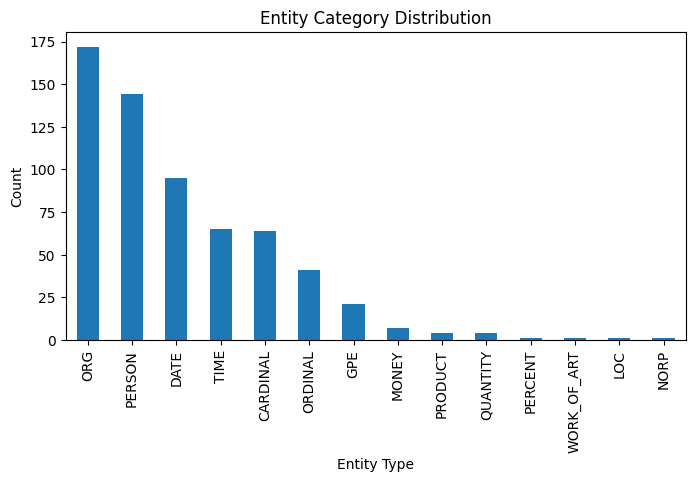

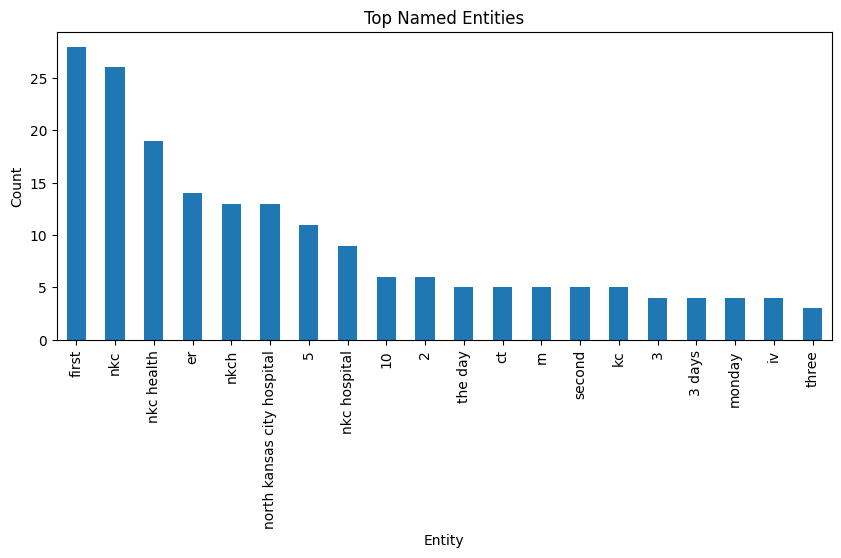

In [ ]:
import matplotlib.pyplot as plt

# Plot entity categories
label_counts.plot(kind='bar', figsize=(8,4), title='Entity Category Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.show()

# Plot top entities
top_entities.plot(kind='bar', figsize=(10,4), title='Top Named Entities')
plt.xlabel('Entity')
plt.ylabel('Count')
plt.show()

In [ ]:
print("SUMMARY OF NAMED ENTITY FINDINGS")
print("--------------------------------")
print("Total named entities:", len(name_entities))
print("After cleaning:", len(name_entities_clean))
print("Unique entities:", name_entities_clean['entity_text_clean'].nunique())

print("\nTop categories:")
print(name_entities_clean['entity_label'].value_counts().head(10))

print("\nTop entities:")
print(name_entities_clean['entity_text_clean'].value_counts().head(10))


SUMMARY OF NAMED ENTITY FINDINGS
--------------------------------
Total named entities: 651
After cleaning: 621
Unique entities: 389

Top categories:
entity_label
ORG         172
PERSON      144
DATE         95
TIME         65
CARDINAL     64
ORDINAL      41
GPE          21
MONEY         7
PRODUCT       4
QUANTITY      4
Name: count, dtype: int64

Top entities:
entity_text_clean
first                         28
nkc                           26
nkc health                    19
er                            14
nkch                          13
north kansas city hospital    13
5                             11
nkc hospital                   9
10                             6
2                              6
Name: count, dtype: int64


In [ ]:
!pip install nltk textblob

In [ ]:
import nltk
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment scores for each review
def sentiment(review):

  # Return missing values if the review is not text
  if(type(review) != str):
    return [np.nan, np.nan, np.nan, np.nan]

  # Get negative, neutral, positive, and compound scores
  sentiment_score = sid.polarity_scores(review)

  return [
      sentiment_score['neg'],
      sentiment_score['neu'],
      sentiment_score['pos'],
      sentiment_score['compound']
  ]

# Add sentiment metrics to the dataset
reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = \
reviews['snippet'].apply(sentiment).apply(pd.Series)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# Describe sentiment values
reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].describe()

,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
count,197.000000,197.000000,197.000000,197.000000
mean,0.051838,0.722604,0.225497,0.584373
std,0.056743,0.102738,0.121785,0.618914
min,0.000000,0.435000,0.000000,-0.994300
25%,0.000000,0.650000,0.131000,0.607700
50%,0.034000,0.734000,0.216000,0.904600
75%,0.081000,0.794000,0.320000,0.960100
max,0.261000,1.000000,0.526000,0.995000


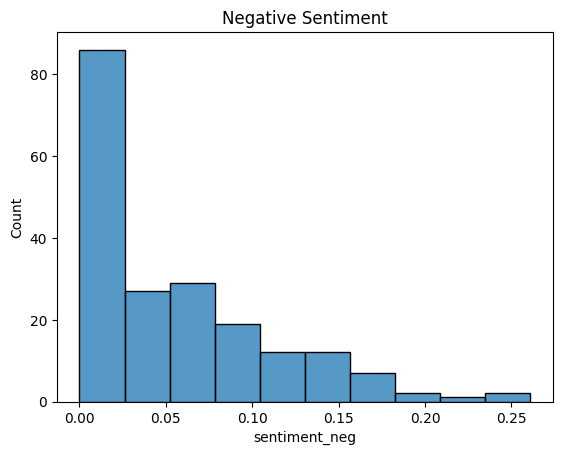

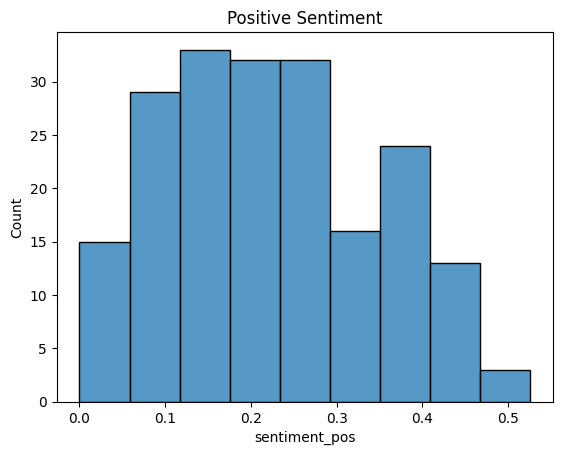

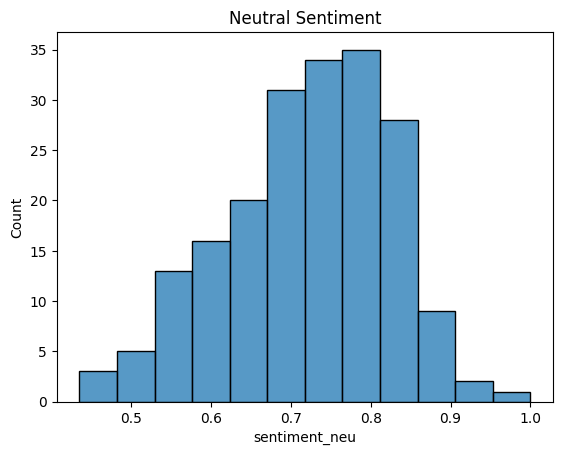

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot negative sentiment distribution
ax = sns.histplot(reviews['sentiment_neg'])
ax.set_title('Negative Sentiment')
plt.show()

# Plot positive sentiment distribution
ax = sns.histplot(reviews['sentiment_pos'])
ax.set_title('Positive Sentiment')
plt.show()

# Plot neutral sentiment distribution
ax = sns.histplot(reviews['sentiment_neu'])
ax.set_title('Neutral Sentiment')
plt.show()

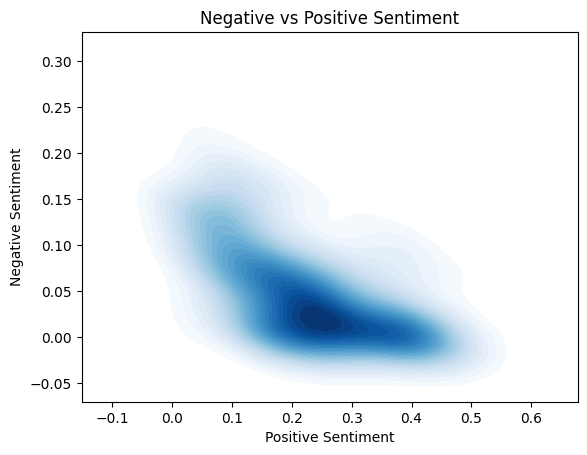

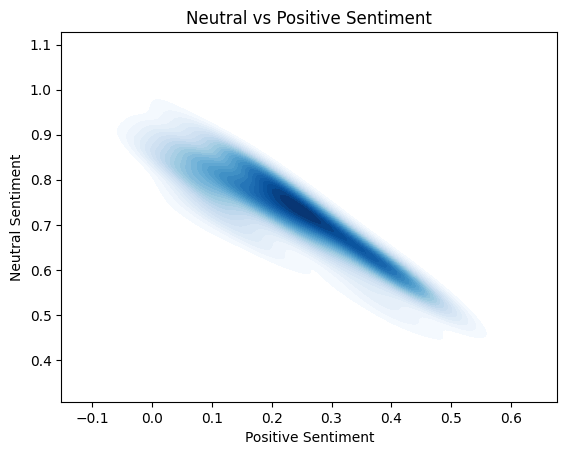

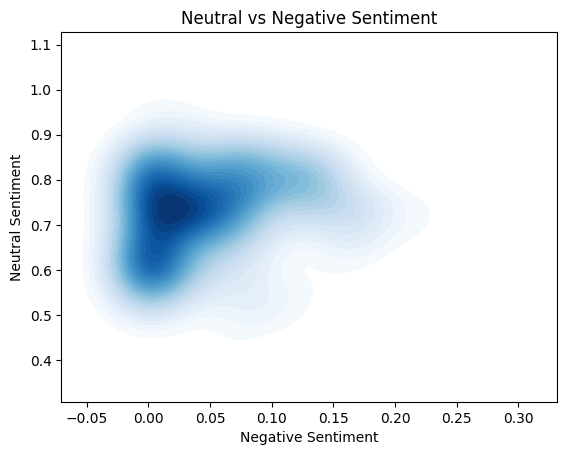

In [ ]:
# Show relationship between positive and negative sentiment
ax = sns.kdeplot(x='sentiment_pos', y='sentiment_neg', data=reviews, fill=True, cmap='Blues', levels=30)
ax.set_xlabel('Positive Sentiment')
ax.set_ylabel('Negative Sentiment')
ax.set_title('Negative vs Positive Sentiment')
plt.show()

# Show relationship between positive and neutral sentiment
ax = sns.kdeplot(x='sentiment_pos', y='sentiment_neu', data=reviews, fill=True, cmap='Blues', levels=30)
ax.set_xlabel('Positive Sentiment')
ax.set_ylabel('Neutral Sentiment')
ax.set_title('Neutral vs Positive Sentiment')
plt.show()

# Show relationship between negative and neutral sentiment
ax = sns.kdeplot(x='sentiment_neg', y='sentiment_neu', data=reviews, fill=True, cmap='Blues', levels=30)
ax.set_xlabel('Negative Sentiment')
ax.set_ylabel('Neutral Sentiment')
ax.set_title('Neutral vs Negative Sentiment')
plt.show()

In [ ]:
# Show average sentiment scores by review rating
reviews.groupby('rating')[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].mean()

,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
rating,,,,
1.0,0.129885,0.767615,0.102500,-0.204500
2.0,0.089400,0.841400,0.069200,-0.127410
3.0,0.116500,0.783125,0.100000,-0.282900
4.0,0.065619,0.744857,0.189476,0.521281
5.0,0.027508,0.697530,0.274902,0.856280


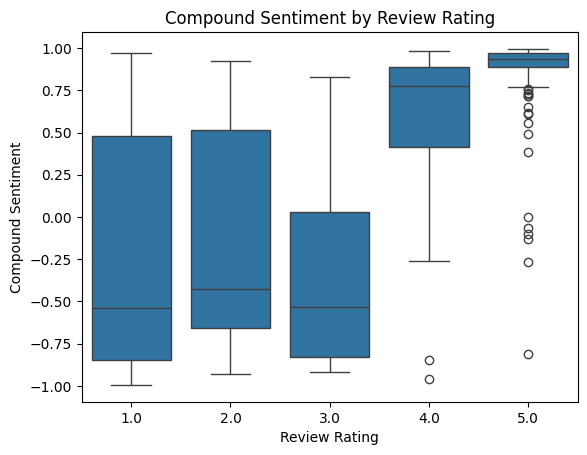

In [ ]:
# Plot compound sentiment against rating
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='rating', y='sentiment_compound', data=reviews)

plt.title('Compound Sentiment by Review Rating')
plt.xlabel('Review Rating')
plt.ylabel('Compound Sentiment')
plt.show()

In [ ]:
# Install transformers for model-based sentiment analysis
!pip install transformers torch

In [ ]:
from transformers import pipeline
import numpy as np

# Load pretrained BERT sentiment model
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment'
)

# Function to compute BERT sentiment
def bert_sentiment(review):

  # Return missing values if the review is not text
  if not isinstance(review, str):
    return [np.nan, np.nan, np.nan]

  # Run model with truncation for long reviews
  result = sentiment_pipeline(review, truncation=True, max_length=512)[0]

  label = result['label']
  score = result['score']

  # Extract star number from label
  stars = int(label[0])

  # Convert stars to sentiment
  # 1-2 stars = negative
  # 3 stars = neutral
  # 4-5 stars = positive
  if stars in [1, 2]:
      sentiment = "negative"
  elif stars == 3:
      sentiment = "neutral"
  else:
      sentiment = "positive"

  return [label, score, sentiment]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Install transformers
!pip install transformers torch

from transformers import pipeline
import numpy as np
import pandas as pd

# Load BERT sentiment model
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment'
)

# Function for BERT sentiment
def bert_sentiment(review):

  if not isinstance(review, str):
    return [np.nan, np.nan, np.nan]

  result = sentiment_pipeline(review, truncation=True, max_length=512)[0]

  label = result['label']   # e.g. "4 stars"
  score = result['score']

  stars = int(label[0])

  # Convert stars → sentiment (your requirement)
  if stars in [1, 2]:
      sentiment = "negative"
  elif stars == 3:
      sentiment = "neutral"
  else:
      sentiment = "positive"

  return [label, score, sentiment]

# Apply BERT to dataset
reviews[['bert_label', 'bert_score', 'bert_sentiment']] = \
reviews['snippet'].apply(bert_sentiment).apply(pd.Series)

# Preview results
reviews[['snippet', 'rating', 'bert_label', 'bert_score', 'bert_sentiment']].head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,snippet,rating,bert_label,bert_score,bert_sentiment
0,My husband and I had an incredible experience ...,5.0,5 stars,0.948671,positive
1,I had the most amazing experience having surge...,5.0,5 stars,0.773896,positive
2,My experience at NKCH was amazing. My nurses a...,5.0,5 stars,0.890416,positive
3,Great service from start to finish. Everybody ...,5.0,5 stars,0.816588,positive
4,I had to stay here a little over a week/week a...,5.0,5 stars,0.838558,positive


In [ ]:
# Add BERT sentiment outputs to the dataset
reviews[['bert_label', 'bert_score', 'bert_sentiment']] = \
reviews['snippet'].apply(bert_sentiment).apply(pd.Series)


# Now display the first few rows with the new sentiment columns
display(reviews[['snippet', 'sentiment_compound', 'bert_label', 'bert_score', 'bert_sentiment']].head())

,snippet,sentiment_compound,bert_label,bert_score,bert_sentiment
0,My husband and I had an incredible experience ...,0.9927,5 stars,0.948671,positive
1,I had the most amazing experience having surge...,0.9639,5 stars,0.773896,positive
2,My experience at NKCH was amazing. My nurses a...,0.9869,5 stars,0.890416,positive
3,Great service from start to finish. Everybody ...,0.9716,5 stars,0.816588,positive
4,I had to stay here a little over a week/week a...,0.9950,5 stars,0.838558,positive


In [ ]:
# Define the vader_label function to categorize compound sentiment scores
def vader_label(compound_score):
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply the vader_label function to create the 'vader_label' column
reviews['vader_label'] = reviews['sentiment_compound'].apply(vader_label)

reviews[['snippet', 'sentiment_compound', 'vader_label']].head()

,snippet,sentiment_compound,vader_label
0,My husband and I had an incredible experience ...,0.9927,positive
1,I had the most amazing experience having surge...,0.9639,positive
2,My experience at NKCH was amazing. My nurses a...,0.9869,positive
3,Great service from start to finish. Everybody ...,0.9716,positive
4,I had to stay here a little over a week/week a...,0.9950,positive


In [ ]:
# Compare BERT sentiment with ratings
pd.crosstab(reviews['bert_sentiment'], reviews['rating'])

rating,1.0,2.0,3.0,4.0,5.0
bert_sentiment,,,,,
negative,25,7,4,5,4
neutral,0,1,4,2,0
positive,1,2,0,14,128


In [ ]:
reviews.groupby('rating')['sentiment_compound'].mean()

,sentiment_compound
rating,
1.0,-0.204500
2.0,-0.127410
3.0,-0.282900
4.0,0.521281
5.0,0.856280


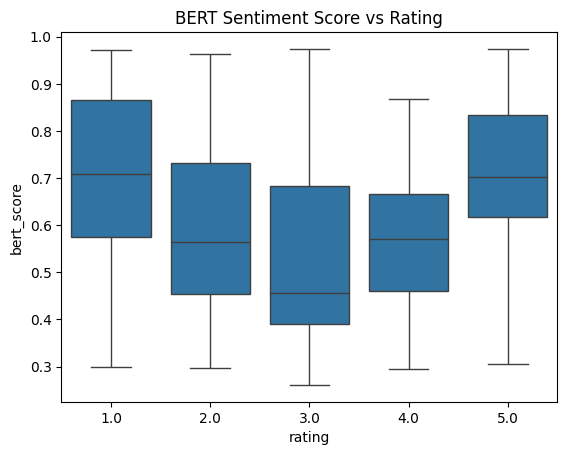

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='rating', y='bert_score', data=reviews)

plt.title('BERT Sentiment Score vs Rating')
plt.show()

In [ ]:
# Filter negative reviews (1 and 2 stars)
negative_reviews = reviews[reviews['rating'] <= 2]

In [ ]:
print("Total negative reviews:", len(negative_reviews))

Total negative reviews: 36


In [ ]:
# Define keywords for different complaint types
complaints = {
    "wait_time": ["wait", "waiting", "hours", "delay", "long time"],
    "staff_attitude": ["rude", "attitude", "disrespectful", "unprofessional"],
    "communication": ["communication", "explained", "didn't tell", "not informed"],
    "billing": ["bill", "charge", "insurance", "cost"],
    "service_quality": ["bad service", "poor care", "mistake", "error"]
}

In [ ]:
# Initialize counts
complaint_counts = {key: 0 for key in complaints}

# Count complaint mentions
for review in negative_reviews['snippet']:
    if not isinstance(review, str):
        continue

    review = review.lower()

    for category, keywords in complaints.items():
        if any(word in review for word in keywords):
            complaint_counts[category] += 1

# Convert to dataframe
complaint_df = pd.DataFrame(list(complaint_counts.items()), columns=['Complaint Type', 'Count'])
complaint_df = complaint_df.sort_values(by='Count', ascending=False)

# Show total negative reviews separately
print("Total negative reviews:", len(negative_reviews))
print("Total complaint mentions counted:", complaint_df['Count'].sum())

complaint_df

Total negative reviews: 36
Total complaint mentions counted: 29


,Complaint Type,Count
0,wait_time,13
1,staff_attitude,9
3,billing,6
2,communication,1
4,service_quality,0


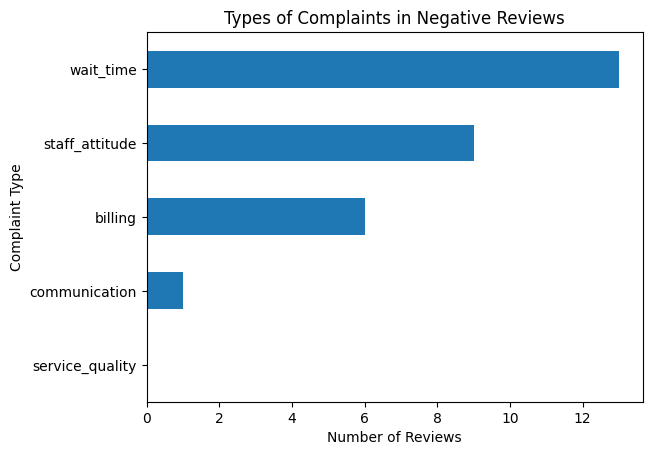

In [ ]:
import matplotlib.pyplot as plt

complaint_df.sort_values(by='Count').plot(
    kind='barh',
    x='Complaint Type',
    y='Count',
    legend=False
)

plt.title('Types of Complaints in Negative Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Complaint Type')
plt.show()

In [ ]:
# Total number of negative reviews
total_negative = len(negative_reviews)
print("Total negative reviews:", total_negative)

# Add percentage of negative reviews mentioning each complaint
complaint_df['Percentage of Negative Reviews (%)'] = (complaint_df['Count'] / total_negative) * 100
complaint_df['Percentage of Negative Reviews (%)'] = complaint_df['Percentage of Negative Reviews (%)'].round(2)

complaint_df

Total negative reviews: 36


,Complaint Type,Count,Percentage of Negative Reviews (%)
0,wait_time,13,36.11
1,staff_attitude,9,25.00
3,billing,6,16.67
2,communication,1,2.78
4,service_quality,0,0.00


In [ ]:
# Total number of complaint mentions across all categories
total_complaints = complaint_df['Count'].sum()
print("Total complaint mentions:", total_complaints)

# Add percentage share of complaint types
complaint_df['Complaint Share (%)'] = (complaint_df['Count'] / total_complaints) * 100
complaint_df['Complaint Share (%)'] = complaint_df['Complaint Share (%)'].round(2)

complaint_df

Total complaint mentions: 29


,Complaint Type,Count,Percentage of Negative Reviews (%),Complaint Share (%)
0,wait_time,13,36.11,44.83
1,staff_attitude,9,25.00,31.03
3,billing,6,16.67,20.69
2,communication,1,2.78,3.45
4,service_quality,0,0.00,0.00


In [ ]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import numpy as np

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

# Load the dataset (ensure reviews is available)
path = "Your/data"
reviews = pd.read_csv(path+'/reviews.csv')

# Initialize VADER sentiment analyzer if not already done
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment scores (copied from previous cell for self-containment)
def sentiment(review):
  if(type(review) != str):
    return [np.nan, np.nan, np.nan, np.nan]
  sentiment_score = sid.polarity_scores(review)
  return [
      sentiment_score['neg'],
      sentiment_score['neu'],
      sentiment_score['pos'],
      sentiment_score['compound']
  ]

# Add sentiment metrics to the dataset (if not already present)
if 'sentiment_compound' not in reviews.columns:
    reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = \
    reviews['snippet'].apply(sentiment).apply(pd.Series)

# Filter negative reviews based on sentiment_compound score (as defined in cell KsjDIgNLXEOK)
negative_reviews = reviews[reviews['sentiment_compound'] < 0].copy()

# Define hospital departments + keywords
departments = {
    "ER / Emergency": ["er", "emergency", "emergency room"],
    "Radiology / Imaging": ["xray", "x-ray", "mri", "ct scan", "imaging", "radiology"],
    "ICU / Critical Care": ["icu", "intensive care", "critical care"],
    "Surgery": ["surgery", "surgical", "operating room", "or"],
    "Laboratory": ["lab", "laboratory", "blood test", "testing"],
    "Pharmacy": ["pharmacy", "medication", "prescription", "drugs"],
    "Neurology": ["neurology", "neurologist"],
    "Cardiology": ["cardiology", "heart", "cardiac"],
}

# Initialize counts
dept_counts = {dept: 0 for dept in departments}

# Loop through negative reviews
for review in negative_reviews["snippet"]:
    if not isinstance(review, str):
        continue

    review_lower = review.lower()

    for dept, keywords in departments.items():
        if any(keyword in review_lower for keyword in keywords):
            dept_counts[dept] += 1

# Convert to DataFrame
dept_df = pd.DataFrame(list(dept_counts.items()), columns=["Department", "Mentions"])
dept_df = dept_df.sort_values(by="Mentions", ascending=False).reset_index(drop=True)

# Sort from highest to lowest
dept_df = dept_df.sort_values(by="Mentions", ascending=False)

print("Most Mentioned Departments in Negative Reviews:")
print(dept_df)

Most Mentioned Departments in Negative Reviews:
            Department  Mentions
0       ER / Emergency        37
1              Surgery        36
2  Radiology / Imaging         7
3           Laboratory         6
4             Pharmacy         6
5  ICU / Critical Care         5
6           Cardiology         3
7            Neurology         1


In [ ]:
import pandas as pd

# Define hospital departments + keywords
departments = {
    "ER / Emergency": ["er", "emergency", "emergency room"],
    "Radiology / Imaging": ["xray", "x-ray", "mri", "ct scan", "imaging", "radiology"],
    "ICU / Critical Care": ["icu", "intensive care", "critical care"],
    "Surgery": ["surgery", "surgical", "operating room", "or"],
    "Laboratory": ["lab", "laboratory", "blood test", "testing"],
    "Pharmacy": ["pharmacy", "medication", "prescription", "drugs"],
    "Neurology": ["neurology", "neurologist"],
    "Cardiology": ["cardiology", "heart", "cardiac"],
}

# Filter positive reviews (adjust threshold if needed)
positive_reviews = reviews[reviews["rating"] >= 4]

# Initialize counts
dept_counts_pos = {dept: 0 for dept in departments}

# Loop through positive reviews
for review in positive_reviews["snippet"]:
    if not isinstance(review, str):
        continue

    review_lower = review.lower()

    for dept, keywords in departments.items():
        if any(keyword in review_lower for keyword in keywords):
            dept_counts_pos[dept] += 1

# Convert to DataFrame
dept_pos_df = pd.DataFrame(list(dept_counts_pos.items()), columns=["Department", "Mentions"])

# Sort descending
dept_pos_df = dept_pos_df.sort_values(by="Mentions", ascending=False)

print("Most Mentioned Departments in Positive Reviews:")
print(dept_pos_df)

Most Mentioned Departments in Positive Reviews:
            Department  Mentions
0       ER / Emergency       150
3              Surgery       132
4           Laboratory        34
1  Radiology / Imaging        18
2  ICU / Critical Care         9
7           Cardiology         9
5             Pharmacy         7
6            Neurology         0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import LatentDirichletAllocation as LDA
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

#if using all reviews
corpus = reviews['snippet']
#if using 30 most negative reviews
#corpus = reviews.sort_values(by = 'sentiment_neg', ascending = False)['snippet'][:30]

mystopwords = ['good','great','patients','nurses','doctors','best','hospital','awesome','place','nkc','nice','north','kansas','city','room','staff','care','experience','everyone','people','one','got','first','well']

#vectorize corpus
count_vect = CountVectorizer(stop_words=stopwords.words('english')+mystopwords, lowercase=True)
x_counts = count_vect.fit_transform(corpus)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
feature_names = count_vect.get_feature_names_out()
#calcuatiing term-frequency times inverse document-frequency (tf-idf)
tfidf_transformer = TfidfTransformer()
x_tfidf = tfidf_transformer.fit_transform(x_counts)
x_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6444 stored elements and shape (197, 2273)>

In [ ]:
import numpy as np

dimension = 3
number_of_words_per_theme = 5

#identifying themes
lda = LDA(n_components = dimension)
lda_array = lda.fit_transform(x_tfidf)

components = [lda.components_[i] for i in range(len(lda.components_))]
important_words = [sorted(feature_names, key = lambda x: components[j][np.where(feature_names == x)], reverse = True)[:number_of_words_per_theme] for j in range(len(components))]
important_words

[['helpful', 'friendly', 'professional', 'surgery', 'procedure'],
 ['surgery', 'get', 'sure', 'treated', 'pain'],
 ['nurse', 'health', 'dr', 'food', 'recommend']]

In [ ]:
import numpy as np

dimension = 4
number_of_words_per_theme = 5

#identifying themes
lda = LDA(n_components = dimension)
lda_array = lda.fit_transform(x_tfidf)

components = [lda.components_[i] for i in range(len(lda.components_))]
important_words = [sorted(feature_names, key = lambda x: components[j][np.where(feature_names == x)], reverse = True)[:number_of_words_per_theme] for j in range(len(components))]
important_words

[['time', 'friendly', 'nurse', 'kind', 'professional'],
 ['health', 'comfortable', 'team', 'helpful', 'recommend'],
 ['everything', 'surgery', 'received', 'caring', 'dr'],
 ['like', 'treated', 'er', 'every', 'doctor']]

In [ ]:
import numpy as np

dimension = 5
number_of_words_per_theme = 5

#identifying themes
lda = LDA(n_components = dimension)
lda_array = lda.fit_transform(x_tfidf)

components = [lda.components_[i] for i in range(len(lda.components_))]
important_words = [sorted(feature_names, key = lambda x: components[j][np.where(feature_names == x)], reverse = True)[:number_of_words_per_theme] for j in range(len(components))]
important_words

[['made', 'surgery', 'pain', 'helpful', 'nurse'],
 ['every', 'time', 'dr', 'lab', 'doctor'],
 ['professional', 'health', 'friendly', 'everything', 'nurse'],
 ['surgery', 'kc', 'procedure', 'took', 'everything'],
 ['amazing', 'kind', 'friendly', 'went', 'helpful']]

In [ ]:
import numpy as np

dimension = 6
number_of_words_per_theme = 5

#identifying themes
lda = LDA(n_components = dimension)
lda_array = lda.fit_transform(x_tfidf)

components = [lda.components_[i] for i in range(len(lda.components_))]
important_words = [sorted(feature_names, key = lambda x: components[j][np.where(feature_names == x)], reverse = True)[:number_of_words_per_theme] for j in range(len(components))]
important_words

[['surgery', 'doctor', 'helpful', 'could', 'entire'],
 ['health', 'everything', 'time', 'recommend', 'caring'],
 ['friendly', 'professional', 'comfortable', 'procedure', 'lady'],
 ['helpful', 'recommend', 'mri', 'stay', 'mom'],
 ['nurse', 'really', 'everything', 'team', 'sure'],
 ['lab', 'treated', 'op', 'nurse', 'really']]

In [ ]:
import pandas as pd
import nltk
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from nltk.corpus import stopwords

# Ensure NLTK data is downloaded if not already present
nltk.download('vader_lexicon', quiet=True)

# Load the dataset (if not already loaded with sentiment)
# Assuming 'path' variable is available from previous cells
path = "Your/data"
reviews = pd.read_csv(path+'/reviews.csv')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment scores for each review
def sentiment(review):
  if(type(review) != str):
    return [np.nan, np.nan, np.nan, np.nan]
  sentiment_score = sid.polarity_scores(review)
  return [
      sentiment_score['neg'],
      sentiment_score['neu'],
      sentiment_score['pos'],
      sentiment_score['compound']
  ]

# Add sentiment metrics to the dataset
reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = \
reviews['snippet'].apply(sentiment).apply(pd.Series)


# Select top 30% most negative reviews
top_30_percent = int(len(reviews) * 0.30)

negative_reviews = reviews.sort_values(
    by='sentiment_neg',
    ascending=False
).head(top_30_percent)

corpus_negative = negative_reviews['snippet'].dropna()

# Define mystopwords (assuming it's defined elsewhere or re-define here for self-containment)
mystopwords = ['good','great','patients','nurses','doctors','best','hospital','awesome','place','nkc','nice','north','kansas','city','room','staff','care','experience','everyone','people','one','got','first','well', 'said']

# Vectorize negative review corpus
count_vect_neg = CountVectorizer(
    stop_words=stopwords.words('english') + mystopwords,
    lowercase=True
)
x_counts_neg = count_vect_neg.fit_transform(corpus_negative)

feature_names_neg = count_vect_neg.get_feature_names_out()

# Calculate tf-idf
tfidf_transformer_neg = TfidfTransformer()
x_tfidf_neg = tfidf_transformer_neg.fit_transform(x_counts_neg)

In [ ]:
number_of_words_per_theme = 5

for dimension in [3, 4, 5, 6]:
    print(f"\n===== Testing {dimension} themes for top 30% most negative reviews =====")

    lda_neg = LDA(n_components=dimension, random_state=42)
    lda_array_neg = lda_neg.fit_transform(x_tfidf_neg)

    components_neg = [lda_neg.components_[i] for i in range(len(lda_neg.components_))]

    important_words_neg = [
        sorted(
            feature_names_neg,
            key=lambda x: components_neg[j][np.where(feature_names_neg == x)],
            reverse=True
        )[:number_of_words_per_theme]
        for j in range(len(components_neg))
    ]

    for i, words in enumerate(important_words_neg):
        print(f"Theme {i+1}: {words}")


===== Testing 3 themes for top 30% most negative reviews =====
Theme 1: ['health', 'treated', 'pain', 'patient', 'professional']
Theme 2: ['back', 'pain', 'nurse', 'work', 'doctor']
Theme 3: ['get', 'pain', 'surgery', '10', 'knowledgeable']

===== Testing 4 themes for top 30% most negative reviews =====
Theme 1: ['doctor', '1045', 'rehab', 'made', 'home']
Theme 2: ['never', 'work', 'go', 'busy', 'team']
Theme 3: ['pain', 'nothing', 'seen', 'back', 'service']
Theme 4: ['pain', 'surgery', 'er', 'caring', '10']

===== Testing 5 themes for top 30% most negative reviews =====
Theme 1: ['1045', 'years', 'doctor', 'professional', 'weeks']
Theme 2: ['er', 'pain', 'back', 'rude', 'billing']
Theme 3: ['service', 'happy', 'amazing', 'nothing', 'toe']
Theme 4: ['health', 'pain', 'mental', 'everything', 'time']
Theme 5: ['pain', 'treated', 'never', 'surgery', 'get']

===== Testing 6 themes for top 30% most negative reviews =====
Theme 1: ['1045', 'disabled', 'early', 'lung', 'punctured']
Theme 2: 

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install pytextrank

In [ ]:
import spacy
import pytextrank

/usr/local/lib/python3.12/dist-packages


In [ ]:
nlp = spacy.load("en_core_web_lg")
nlp.add_pipe("textrank")

In [ ]:
reviews['length'] = reviews['snippet'].astype(str).apply(lambda x: len(x))

In [ ]:
reviews['rating'] = pd.to_numeric(reviews['rating'], errors='coerce')

In [ ]:
high_reviews = reviews[reviews['rating'] >= 4].sort_values(by='length', ascending=False).head(10)
high_reviews

,Unnamed: 0,position,link,rating,date,iso_date,iso_date_of_last_edit,source,review_id,user,snippet,extracted_snippet,likes,response,images,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,length
152,4,5,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2024-09-10T15:39:18Z,2024-09-10T15:39:18Z,Google,ChZDSUhNMG9nS0VJQ0FnSUNIbl9tTWZBEAE,"{'name': 'Melanie S', 'link': 'https://www.goo...",This was my post the day after surgery:\nYeste...,{'original': 'This was my post the day after s...,0,"{'date': 'a year ago', 'iso_date': '2024-09-11...",['https://lh3.googleusercontent.com/grass-cs/A...,0.006,0.832,0.162,0.9948,1765
4,4,5,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2025-12-23T10:58:40Z,2025-12-23T11:12:55Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25kamNqbG5VMFJmVW5wRl...,"{'name': 'A K', 'link': 'https://www.google.co...",I had to stay here a little over a week/week a...,{'original': 'I had to stay here a little over...,0,"{'date': '4 months ago', 'iso_date': '2025-12-...",NaN,0.036,0.745,0.220,0.9950,1400
8,0,1,https://www.google.com/maps/reviews/data=!4m8!...,4.0,2 months ago,2026-02-21T21:50:36Z,2026-02-21T21:50:36Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25aaUxVZHpOWFZpWlhkRl...,"{'name': 'Elizabeth Nelson', 'link': 'https://...",After breaking my femur and being transported ...,{'original': 'After breaking my femur and bein...,0,NaN,NaN,0.175,0.728,0.097,-0.9607,1251
16,8,9,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2026-01-09T15:28:46Z,2026-01-09T15:28:46Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2xKTWIzVTNUMjl1YjBwdm...,"{'name': 'Donna Geisinger', 'link': 'https://w...",My husband & I go to KUMed for my Leqembi Infu...,{'original': 'My husband & I go to KUMed for m...,0,"{'date': '3 months ago', 'iso_date': '2026-01-...",NaN,0.008,0.827,0.165,0.9836,1181
0,0,1,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2025-12-23T16:55:31Z,2025-12-23T16:55:31Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,"{'name': 'Ashley Taylor', 'link': 'https://www...",My husband and I had an incredible experience ...,{'original': 'My husband and I had an incredib...,0,"{'date': '4 months ago', 'iso_date': '2025-12-...",NaN,0.014,0.739,0.247,0.9927,1172
193,5,6,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2025-03-03T14:07:57Z,2025-03-03T14:07:57Z,Google,ChdDSUhNMG9nS0VJQ0FnTUNROHJlQnp3RRAB,"{'name': 'Megan Kasper', 'link': 'https://www....",Dr. Wayman! Amazing O.B. & so glad you brought...,"{'original': ""Dr. Wayman! Amazing O.B. & so gl...",0,"{'date': 'a year ago', 'iso_date': '2025-03-03...",NaN,0.015,0.753,0.231,0.9944,1081
6,6,7,https://www.google.com/maps/reviews/data=!4m8!...,5.0,3 months ago,2026-02-06T17:09:31Z,2026-02-06T17:09:31Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2sxMmRHbG5jbTVXWlhGTm...,"{'name': 'Aaron Baker', 'link': 'https://www.g...","Really good experience with pre op nurses, sur...","{'original': ""Really good experience with pre ...",0,NaN,NaN,0.063,0.806,0.131,0.9291,1026
43,5,6,https://www.google.com/maps/reviews/data=!4m8!...,5.0,7 months ago,2025-09-29T16:54:58Z,2025-09-29T16:54:58Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2tsUWRXY3dVWGg0UTNGdm...,"{'name': ""Dot's Office products"", 'link': 'htt...",My recent experience with having a right knee ...,{'original': 'My recent experience with having...,0,"{'date': '7 months ago', 'iso_date': '2025-09-...",NaN,0.000,0.794,0.206,0.9889,1006
189,1,2,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2025-04-22T17:48:48Z,2025-04-22T17:48:48Z,Google,ChdDSUhNMG9nS0VJQ0FnTURvN1BfTy13RRAB,"{'name': 'Ramona Harris-Smith', 'link': 'https...",Every single time I visit North Kansas City Ho...,"{'original': ""Every single time I visit North ...",0,"{'date': 'a year ago', 'iso_date': '2025-04-24...",NaN,0.021,0.783,0.196,0.9889,976
80,2,3,https://www.google.com/maps/reviews/data=!4m8!...,5.0,8 months ago,2025-08-22T16:30:41Z,2025-08-22T16:30:41Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2pVdFZVRmxjV

In [ ]:
low_reviews = reviews[reviews['rating'] <= 2].sort_values(by='length', ascending=False).head(10)
low_reviews

,Unnamed: 0,position,link,rating,date,iso_date,iso_date_of_last_edit,source,review_id,user,snippet,extracted_snippet,likes,response,images,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,length
52,4,5,https://www.google.com/maps/reviews/data=!4m8!...,1.0,7 months ago,2025-10-09T03:17:44Z,2025-10-09T03:17:44Z,Google,Ci9DQUlRQUNvZENodHljRjlvT210dFJrRmpjUzA0Tkhwal...,"{'name': 'Jessica Nelson', 'link': 'https://ww...","This place is awful! Poor communication, loud ...",{'original': 'This place is awful! Poor commun...,0,"{'date': '6 months ago', 'iso_date': '2025-10-...",NaN,0.164,0.751,0.085,-0.9943,2999
160,2,3,https://www.google.com/maps/reviews/data=!4m8!...,1.0,Edited 7 months ago,2025-09-12T18:48:47Z,2025-09-16T12:33:36Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2paT00wRXdkWEExYldONl...,"{'name': 'Adora Russell', 'link': 'https://www...","Got admitted, told them SEVERAL times I couldn...","{'original': 'Got admitted, told them SEVERAL ...",0,NaN,NaN,0.108,0.801,0.092,-0.6840,1794
49,1,2,https://www.google.com/maps/reviews/data=!4m8!...,2.0,7 months ago,2025-09-26T18:21:54Z,2025-09-26T18:21:54Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2w5b00yMVJUWEYyVjIxNV...,"{'name': 'Kristen Dasilva', 'link': 'https://w...",Dr. Distacio is amazing but I wish she worked ...,{'original': 'Dr. Distacio is amazing but I wi...,0,"{'date': '7 months ago', 'iso_date': '2025-09-...",NaN,0.022,0.925,0.053,0.8353,1386
64,6,7,https://www.google.com/maps/reviews/data=!4m8!...,1.0,7 months ago,2025-09-27T02:19:16Z,2025-09-27T02:19:16Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25CV2JUWnNiV0ozVHpoRV...,"{'name': 'Elizabeth Wandell', 'link': 'https:/...",Very disappointed. Waited over 5 hours to be s...,"{'original': ""Very disappointed. Waited over 5...",0,NaN,NaN,0.147,0.756,0.097,-0.6513,1284
124,6,7,https://www.google.com/maps/reviews/data=!4m8!...,2.0,8 months ago,2025-08-29T15:20:15Z,2025-08-29T15:20:39Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2xSWmRVWXdiSFppVVRaRV...,"{'name': 'Aubry Hilderhof', 'link': 'https://w...",Not the best experience. My surgery was switch...,"{'original': ""Not the best experience. My surg...",0,NaN,NaN,0.065,0.861,0.074,0.6225,1225
145,7,8,https://www.google.com/maps/reviews/data=!4m8!...,1.0,8 months ago,2025-08-13T16:29:08Z,2025-08-13T16:29:08Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2xaRk0zcEZiVTFyWTJWeF...,"{'name': 'Laura Hibbs', 'link': 'https://www.g...",Extremely disappointed in treatment this far w...,{'original': 'Extremely disappointed in treatm...,0,"{'date': '8 months ago', 'iso_date': '2025-08-...",NaN,0.059,0.826,0.115,0.9170,1199
192,4,5,https://www.google.com/maps/reviews/data=!4m8!...,1.0,a year ago,2025-03-26T18:32:46Z,2025-03-26T18:55:47Z,Google,ChZDSUhNMG9nS0VJQ0FnTUR3eWNLRk9REAE,"{'name': 'Reed Pattee', 'link': 'https://www.g...","I was admitted for 4 days, drugged up, told I ...","{'original': ""I was admitted for 4 days, drugg...",0,"{'date': 'a year ago', 'iso_date': '2025-04-03...",NaN,0.076,0.749,0.175,0.9737,1113
61,3,4,https://www.google.com/maps/reviews/data=!4m8!...,1.0,7 months ago,2025-09-27T21:20:18Z,2025-09-27T21:20:18Z,Google,Ci9DQUlRQUNvZENodHljRjlvT21kSE56WkpaRGwwWlhsSE...,"{'name': 'Sydney Cullen', 'link': 'https://www...",Extremely disappointed with the care provided....,{'original': 'Extremely disappointed with the ...,0,NaN,NaN,0.053,0.830,0.116,0.8967,1089
24,6,7,https://www.google.com/maps/reviews/data=!4m8!...,2.0,7 months ago,2025-10-05T16:30:27Z,2025-10-05T16:30:27Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25OWldtOUNiekJNYUZnM1...,"{'name': 'Karen Unfolded', 'link': 'https://ww...",After I got out of the emergency room waiting ...,"{'original': ""After I got out of the emergency...",0,"{'date': '6 months ago', 'iso_date': '2025-10-...",NaN,0.134,0.711,0.155,-0.6762,1045
34,6,7,https://www.google.com/maps/reviews/data=!4m8!...,2.0,3 months ago,2026-01-22T20:26:36Z,2026-01-22T20:26:36Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25ZMlEyZFVlR3czYUdKdm...,"{'name': 'Ernestine Gibson', 'link': 'https://...",I have been coming to NK

In [ ]:
selected_reviews = pd.concat([high_reviews, low_reviews]).reset_index(drop=True)
selected_reviews

,Unnamed: 0,position,link,rating,date,iso_date,iso_date_of_last_edit,source,review_id,user,snippet,extracted_snippet,likes,response,images,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,length
0,4,5,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2024-09-10T15:39:18Z,2024-09-10T15:39:18Z,Google,ChZDSUhNMG9nS0VJQ0FnSUNIbl9tTWZBEAE,"{'name': 'Melanie S', 'link': 'https://www.goo...",This was my post the day after surgery:\nYeste...,{'original': 'This was my post the day after s...,0,"{'date': 'a year ago', 'iso_date': '2024-09-11...",['https://lh3.googleusercontent.com/grass-cs/A...,0.006,0.832,0.162,0.9948,1765
1,4,5,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2025-12-23T10:58:40Z,2025-12-23T11:12:55Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25kamNqbG5VMFJmVW5wRl...,"{'name': 'A K', 'link': 'https://www.google.co...",I had to stay here a little over a week/week a...,{'original': 'I had to stay here a little over...,0,"{'date': '4 months ago', 'iso_date': '2025-12-...",NaN,0.036,0.745,0.220,0.9950,1400
2,0,1,https://www.google.com/maps/reviews/data=!4m8!...,4.0,2 months ago,2026-02-21T21:50:36Z,2026-02-21T21:50:36Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25aaUxVZHpOWFZpWlhkRl...,"{'name': 'Elizabeth Nelson', 'link': 'https://...",After breaking my femur and being transported ...,{'original': 'After breaking my femur and bein...,0,NaN,NaN,0.175,0.728,0.097,-0.9607,1251
3,8,9,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2026-01-09T15:28:46Z,2026-01-09T15:28:46Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2xKTWIzVTNUMjl1YjBwdm...,"{'name': 'Donna Geisinger', 'link': 'https://w...",My husband & I go to KUMed for my Leqembi Infu...,{'original': 'My husband & I go to KUMed for m...,0,"{'date': '3 months ago', 'iso_date': '2026-01-...",NaN,0.008,0.827,0.165,0.9836,1181
4,0,1,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 months ago,2025-12-23T16:55:31Z,2025-12-23T16:55:31Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2s5YU1XbE1jVWx6VjFsdl...,"{'name': 'Ashley Taylor', 'link': 'https://www...",My husband and I had an incredible experience ...,{'original': 'My husband and I had an incredib...,0,"{'date': '4 months ago', 'iso_date': '2025-12-...",NaN,0.014,0.739,0.247,0.9927,1172
5,5,6,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2025-03-03T14:07:57Z,2025-03-03T14:07:57Z,Google,ChdDSUhNMG9nS0VJQ0FnTUNROHJlQnp3RRAB,"{'name': 'Megan Kasper', 'link': 'https://www....",Dr. Wayman! Amazing O.B. & so glad you brought...,"{'original': ""Dr. Wayman! Amazing O.B. & so gl...",0,"{'date': 'a year ago', 'iso_date': '2025-03-03...",NaN,0.015,0.753,0.231,0.9944,1081
6,6,7,https://www.google.com/maps/reviews/data=!4m8!...,5.0,3 months ago,2026-02-06T17:09:31Z,2026-02-06T17:09:31Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2sxMmRHbG5jbTVXWlhGTm...,"{'name': 'Aaron Baker', 'link': 'https://www.g...","Really good experience with pre op nurses, sur...","{'original': ""Really good experience with pre ...",0,NaN,NaN,0.063,0.806,0.131,0.9291,1026
7,5,6,https://www.google.com/maps/reviews/data=!4m8!...,5.0,7 months ago,2025-09-29T16:54:58Z,2025-09-29T16:54:58Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2tsUWRXY3dVWGg0UTNGdm...,"{'name': ""Dot's Office products"", 'link': 'htt...",My recent experience with having a right knee ...,{'original': 'My recent experience with having...,0,"{'date': '7 months ago', 'iso_date': '2025-09-...",NaN,0.000,0.794,0.206,0.9889,1006
8,1,2,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a year ago,2025-04-22T17:48:48Z,2025-04-22T17:48:48Z,Google,ChdDSUhNMG9nS0VJQ0FnTURvN1BfTy13RRAB,"{'name': 'Ramona Harris-Smith', 'link': 'https...",Every single time I visit North Kansas City Ho...,"{'original': ""Every single time I visit North ...",0,"{'date': 'a year ago', 'iso_date': '2025-04-24...",NaN,0.021,0.783,0.196,0.9889,976
9,2,3,https://www.google.com/maps/reviews/data=!4m8!...,5.0,8 months ago,2025-08-22T16:30:41Z,2025-08-22T16:30:41Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2pVdFZVRmxjVWhWWldOc1

In [ ]:
for i, row in selected_reviews.iterrows():
    print(f"\n================ REVIEW {i+1} ================\n")
    print(f"Rating: {row['rating']}")
    print(f"Review Type: {'High' if row['rating'] >= 4 else 'Low'}\n")

    review_text = str(row['snippet'])

    # Apply TextRank (PageRank-based)
    doc = nlp(review_text)
    extractive_summary = doc._.textrank.summary(limit_sentences=2, limit_phrases=5)

    print("Extractive Summary:")
    for sentence in extractive_summary:
        display(sentence)


================ REVIEW 1 ================

Rating: 5.0
Review Type: High

Extractive Summary:


I had to wear my KC Bleacher Mom LLC Chiefs Kingdom Strong shirt, of course!


This was my post the day after surgery:
Yesterday was surgery day.


================ REVIEW 2 ================

Rating: 5.0
Review Type: High

Extractive Summary:


If I had to go anywhere for treatment again I would come back here with no hesitation.(the food is also not bad at all for, hospital food it was actually good the food staff and house keeping are amazing and kind people as well).


...

While in the ER I was in a #10 state of pain with kidney stones.

The ER staff were fine also, but the waiting so long to be seen was very very difficult considering my level of pain!


================ REVIEW 20 ================

Rating: 2.0
Review Type: Low

Extractive Summary:


I have been coming to NKC hospital for years now for a certain type of doctor.

There are things in life that you can't put a dollar sign on it.

In [ ]:
for i, row in selected_reviews.iterrows():
    print(f"\n================ REVIEW {i+1} PHRASES ================\n")

    review_text = str(row['snippet'])

    # Apply TextRank again
    doc = nlp(review_text)

    print("Top Ranked Phrases:")
    for phrase in doc._.phrases[0:10]:
        print(phrase.text, phrase.rank, phrase.count)
        print(phrase.chunks)


================ REVIEW 1 PHRASES ================

Top Ranked Phrases:
KC Bleacher Mom LLC Chiefs 0.08531533376936679 1
[KC Bleacher Mom LLC Chiefs]
surgery day 0.07975386987714021 2
[surgery day, surgery day]
surgery 0.06496129751585913 2
[surgery, surgery]
my KC Bleacher Mom LLC Chiefs Kingdom Strong shirt 0.06481337415683687 1
[my KC Bleacher Mom LLC Chiefs Kingdom Strong shirt]
Kip 0.06259511054818377 6
[Kip, Kip, Kip, Kip, Kip, Kip]
Kansas City 0.060780561667132756 2
[Kansas City, Kansas City]
Kingdom Strong 0.05978823789162685 1
[Kingdom Strong]
excellent job 0.058662630816494955 1
[excellent job]
Orthopedic Health 0.0585121107629881 2
[Orthopedic Health, Orthopedic Health]
Sara Stedy 0.05783658649610246 1
[Sara Stedy]

================ REVIEW 2 PHRASES ================

Top Ranked Phrases:
treatment 0.08828161266192318 2
[treatment, treatment]
hospital food 0.08425019642981192 1
[hospital food]
house keeping 0.07451314338184614 1
[house keeping]
amazing and kind people 0.06751

In [ ]:
from transformers import pipeline
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

model_name = model_name = "google/pegasus-x-large"

In [ ]:
!nvidia-smi

Sun May 10 02:19:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             26W /   70W |    1503MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
pegasus_model = PegasusForConditionalGeneration.from_pretrained(model_name).to(device)
pegasus_tokenizer = PegasusTokenizer.from_pretrained(model_name)

def pegasus_summarize(text, max_len):
  tokens = pegasus_tokenizer(text, truncation=True, padding="longest", return_tensors="pt").to(device)
  encoded_summary = pegasus_model.generate(**tokens, max_length=max_len)
  decoded_summary = pegasus_tokenizer.decode(encoded_summary[0], skip_special_tokens=True)
  return decoded_summary

config.json: 0.00B [00:00, ?B/s]

You are using a model of type pegasus_x to instantiate a model of type pegasus. This is not supported for all configurations of models and can yield errors.


pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/262 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
max_len = 64

for i, row in selected_reviews.iterrows():
    print(f"\n================ REVIEW {i+1} ================\n")
    print(f"Rating: {row['rating']}")
    print(f"Review Type: {'High' if row['rating'] >= 4 else 'Low'}\n")

    review_text = str(row['snippet'])

    # Generate abstractive summary
    abstractive_summary = pegasus_summarize(review_text, max_len)

    print("Abstractive Summary:")
    print(abstractive_summary)


================ REVIEW 1 ================

Rating: 5.0
Review Type: High

Abstractive Summary:
Kim was the anesthesiologist, Paul was the nurse anesthetist, Marty my pre-op nurse, Lotha was the most hilarious tech who took me to the bathroom on the Sara Stedy (she was a riot!), Cheryl, RN prayed with Kip and me before wheeling me off, and Ashley was my post

================ REVIEW 2 ================

Rating: 5.0
Review Type: High

Abstractive Summary:
If I had to go anywhere for treatment again I would come back here with no hesitation.(the food is also not bad at all for, hospital food it was actually good the food staff and house keeping are amazing and kind people as well).

================ REVIEW 3 ================

Rating: 4.0
Review Type: High

Abstractive Summary:
After breaking my femur and being transported to Liberty Hospital ER, where I received no attention other than vitals being taken - and I was left in a hallway in a wheelchair sobbing uncontrollably because of pain

In [ ]:
extractive_list = []
abstractive_list = []

for _, row in selected_reviews.iterrows():
    text = str(row['snippet'])

    # Extractive
    doc = nlp(text)
    ext = " ".join([sent.text for sent in doc._.textrank.summary(limit_sentences=2)])

    # Abstractive
    abs_sum = pegasus_summarize(text, max_len=60)

    extractive_list.append(ext)
    abstractive_list.append(abs_sum)

selected_reviews['extractive_summary'] = extractive_list
selected_reviews['abstractive_summary'] = abstractive_list

# Final table
selected_reviews[['rating', 'snippet', 'extractive_summary', 'abstractive_summary']]

,rating,snippet,extractive_summary,abstractive_summary
0,5.0,This was my post the day after surgery:\nYeste...,I had to wear my KC Bleacher Mom LLC Chiefs Ki...,"Kim was the anesthesiologist, Paul was the nur..."
1,5.0,I had to stay here a little over a week/week a...,If I had to go anywhere for treatment again I ...,If I had to go anywhere for treatment again I ...
2,4.0,After breaking my femur and being transported ...,After breaking my femur and being transported ...,After breaking my femur and being transported ...
3,5.0,My husband & I go to KUMed for my Leqembi Infu...,"Prior to getting to my area, I was weighted th...","After getting that info, the nurse left & came..."
4,5.0,My husband and I had an incredible experience ...,A huge shout-out to our wonderful nurses: Rach...,A huge shout-out to our wonderful nurses: Rach...
5,5.0,Dr. Wayman! Amazing O.B. & so glad you brought...,She put him straight on my chest for skin to s...,The whole team shared with me what was next at...
6,5.0,"Really good experience with pre op nurses, sur...","Really good experience with pre op nurses, sur...","However, they're job is to make you feel comfo..."
7,5.0,My recent experience with having a right knee ...,"The various medical Doctors who were involved,...",Our region is blessed with having this hospita...
8,5.0,Every single time I visit North Kansas City Ho...,It was like having an Angel walking beside us ...,"Daniels didn't know, is that my Mom and I need..."
9,5.0,I cannot say enough wonderful things about my ...,I cannot say enough wonderful things about my ...,I cannot say enough wonderful things about my ...



Top 20 Bigrams:
              Bigram  Count
0         nkc health     21
1        kansas city     17
2       nkc hospital     15
3       north kansas     15
4      city hospital     14
5          made feel     13
6     emergency room     12
7     labor delivery     11
8          made sure     11
9      nursing staff      9
10         make sure      9
11    doctors nurses      8
12  feel comfortable      8
13            pre op      7
14        thank much      6
15  sure comfortable      6
16       entire time      6
17   good experience      6
18        every time      6
19        would give      6


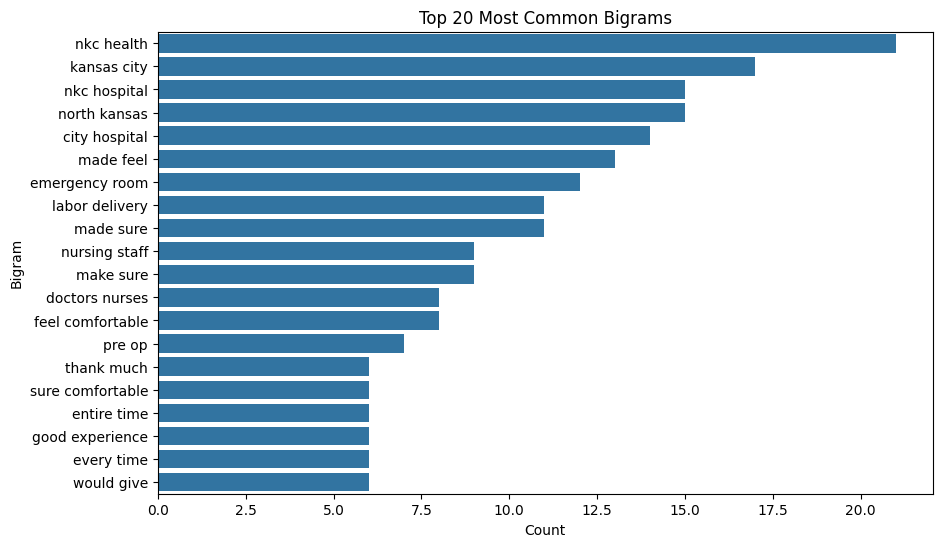


Top 20 Trigrams:
                    Trigram  Count
0         north kansas city     15
1      kansas city hospital     14
2     made sure comfortable      5
3     made feel comfortable      5
4        could asked better      4
5       primary care doctor      4
6     maternal child health      3
7            every step way      3
8   experience north kansas      3
9            took good care      3
10         made feel valued      3
11             come talk us      3
12    experience nkc health      3
13         went beyond make      3
14        north kc hospital      3
15         new primary care      3
16        team nkc hospital      2
17     took time thoroughly      2
18          entire team nkc      2
19       surgery nkc health      2


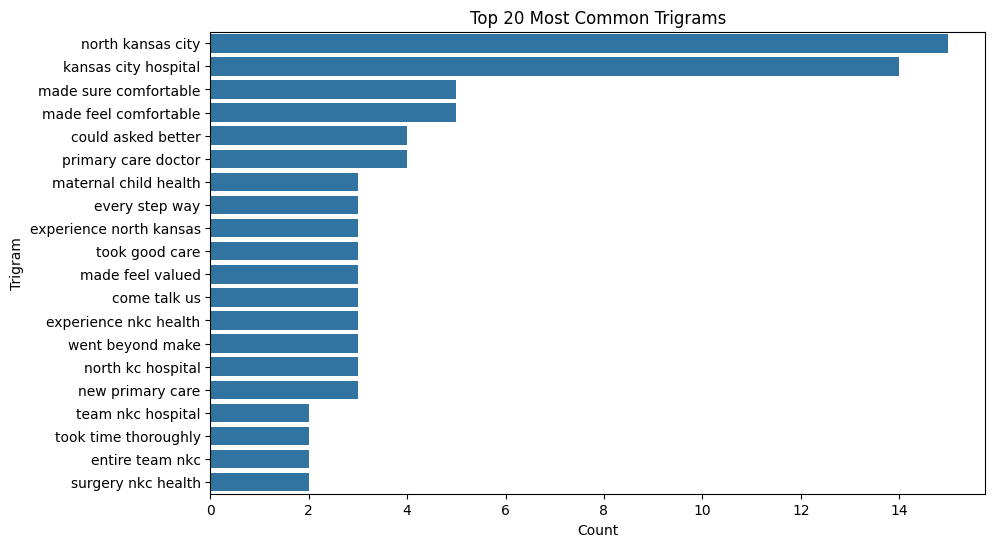

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load reviews if not already loaded (assuming 'reviews' DataFrame is available)
# If 'reviews' is not available from previous cells, you might need to reload it here:
# path = "Your/data"
# reviews = pd.read_csv(path + '/reviews.csv')

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text) # Remove non-word characters
    text = re.sub(r'\s+', ' ', text) # Replace multiple spaces with a single space
    return text

reviews['cleaned_snippet'] = reviews['snippet'].apply(clean_text)

stop_words = set(stopwords.words('english'))

def generate_ngrams(text, n):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return list(ngrams(tokens, n))

# Bigrams
bigrams_list = []
for text in reviews['cleaned_snippet']:
    bigrams_list.extend(generate_ngrams(text, 2))

bigram_counts = Counter(bigrams_list)
top_bigrams = pd.DataFrame(bigram_counts.most_common(20), columns=['Bigram', 'Count'])
top_bigrams['Bigram'] = top_bigrams['Bigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Bigrams:")
print(top_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Bigram', data=top_bigrams)
plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

# Trigrams
trigrams_list = []
for text in reviews['cleaned_snippet']:
    trigrams_list.extend(generate_ngrams(text, 3))

trigram_counts = Counter(trigrams_list)
top_trigrams = pd.DataFrame(trigram_counts.most_common(20), columns=['Trigram', 'Count'])
top_trigrams['Trigram'] = top_trigrams['Trigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Trigrams:")
print(top_trigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Trigram', data=top_trigrams)
plt.title('Top 20 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.



Top 20 Bigrams in Negative Reviews:
                  Bigram  Count
0         blood pressure      5
1           north kansas      4
2            kansas city      4
3          city hospital      4
4              pain meds      4
5             would give      4
6          kidney stones      4
7          mental health      4
8          several times      3
9   driving restrictions      3
10             made feel      3
11            nkc health      3
12         love hospital      2
13           another day      2
14      liberty hospital      2
15             told wait      2
16            pain first      2
17            every time      2
18   polite professional      2
19           go hospital      2


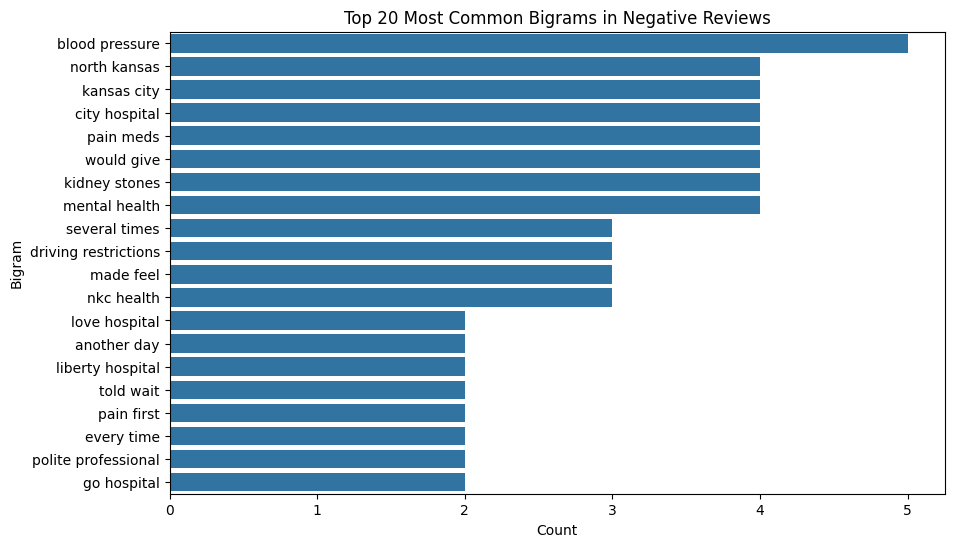


Top 20 Trigrams in Negative Reviews:
                    Trigram  Count
0         north kansas city      4
1      kansas city hospital      4
2         major dental work      2
3       primary care doctor      2
4       blood pressure meds      2
5             taken back er      2
6        said come hospital      2
7          sit waiting room      2
8   staff outstanding issue      1
9   outstanding issue would      1
10         issue would ever      1
11      would ever hospital      1
12       ever hospital beds      1
13       hospital beds pole      1
14         beds pole almost      1
15   pole almost unbearable      1
16    almost unbearable lay      1
17       unbearable lay say      1
18              lay say bad      1
19           say bad toilet      1


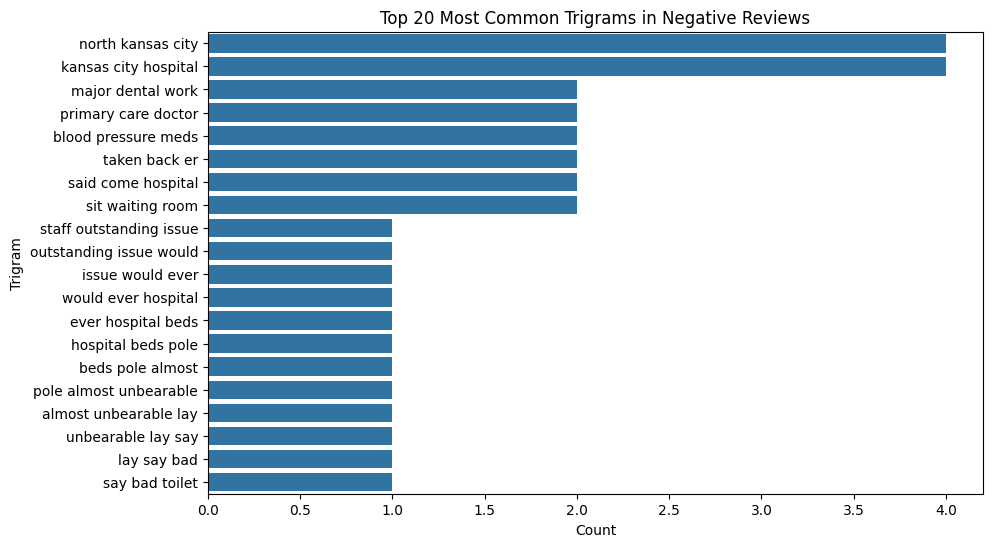

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added numpy import
from nltk.sentiment import SentimentIntensityAnalyzer # Added SentimentIntensityAnalyzer import

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('vader_lexicon', quiet=True) # Added VADER lexicon download

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment scores for each review
def sentiment(review):
  # Return missing values if the review is not text
  if(type(review) != str):
    return [np.nan, np.nan, np.nan, np.nan]

  # Get negative, neutral, positive, and compound scores
  sentiment_score = sid.polarity_scores(review)

  return [
      sentiment_score['neg'],
      sentiment_score['neu'],
      sentiment_score['pos'],
      sentiment_score['compound']
  ]

# Add sentiment metrics to the dataset
reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = \
reviews['snippet'].apply(sentiment).apply(pd.Series)

# Filter for negative reviews based on sentiment_compound score
# A common threshold for negative sentiment is sentiment_compound < 0
negative_reviews = reviews[reviews['sentiment_compound'] < 0].copy()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text) # Remove non-word characters
    text = re.sub(r'\s+', ' ', text) # Replace multiple spaces with a single space
    return text

negative_reviews['cleaned_snippet'] = negative_reviews['snippet'].apply(clean_text)

stop_words = set(stopwords.words('english'))

def generate_ngrams(text, n):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return list(ngrams(tokens, n))

# Bigrams for negative reviews
neg_bigrams_list = []
for text in negative_reviews['cleaned_snippet']:
    neg_bigrams_list.extend(generate_ngrams(text, 2))

neg_bigram_counts = Counter(neg_bigrams_list)
top_neg_bigrams = pd.DataFrame(neg_bigram_counts.most_common(20), columns=['Bigram', 'Count'])
top_neg_bigrams['Bigram'] = top_neg_bigrams['Bigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Bigrams in Negative Reviews:")
print(top_neg_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Bigram', data=top_neg_bigrams)
plt.title('Top 20 Most Common Bigrams in Negative Reviews')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

# Trigrams for negative reviews
neg_trigrams_list = []
for text in negative_reviews['cleaned_snippet']:
    neg_trigrams_list.extend(generate_ngrams(text, 3))

neg_trigram_counts = Counter(neg_trigrams_list)
top_neg_trigrams = pd.DataFrame(neg_trigram_counts.most_common(20), columns=['Trigram', 'Count'])
top_neg_trigrams['Trigram'] = top_neg_trigrams['Trigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Trigrams in Negative Reviews:")
print(top_neg_trigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Trigram', data=top_neg_trigrams)
plt.title('Top 20 Most Common Trigrams in Negative Reviews')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()


Top 20 Bigrams in Positive Reviews:
              Bigram  Count
0         nkc health     18
1       nkc hospital     13
2        kansas city     13
3     labor delivery     11
4          made sure     11
5       north kansas     11
6          made feel     10
7     emergency room     10
8      city hospital     10
9      nursing staff      8
10         make sure      8
11    doctors nurses      7
12  feel comfortable      7
13  sure comfortable      6
14      asked better      6
15     care received      6
16   would recommend      6
17         took time      5
18        say enough      5
19       entire team      5


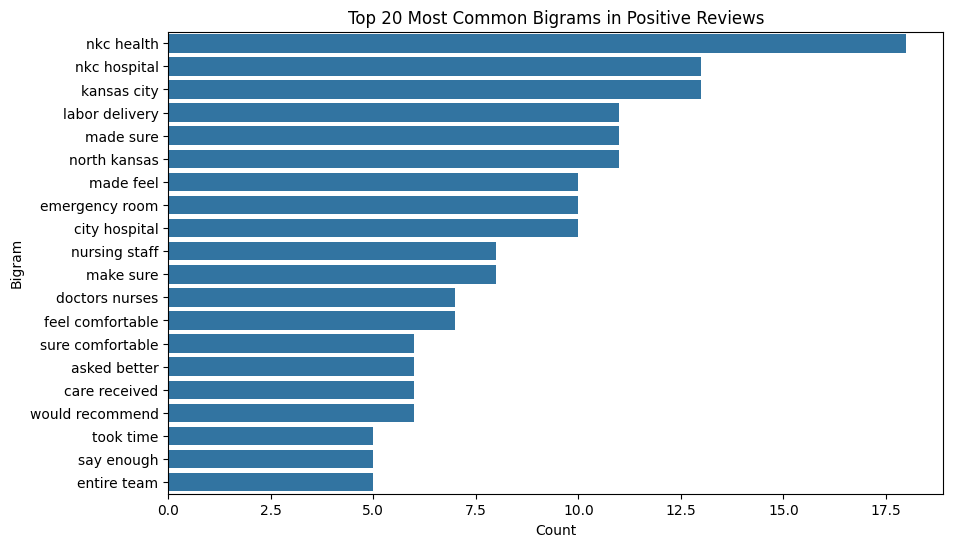


Top 20 Trigrams in Positive Reviews:
                    Trigram  Count
0         north kansas city     11
1      kansas city hospital     10
2     made sure comfortable      5
3     made feel comfortable      4
4        could asked better      4
5     maternal child health      3
6            every step way      3
7   experience north kansas      3
8            took good care      3
9          made feel valued      3
10             come talk us      3
11    experience nkc health      3
12         went beyond make      3
13        north kc hospital      3
14         new primary care      3
15        team nkc hospital      2
16     took time thoroughly      2
17          entire team nkc      2
18       surgery nkc health      2
19          nurse took care      2


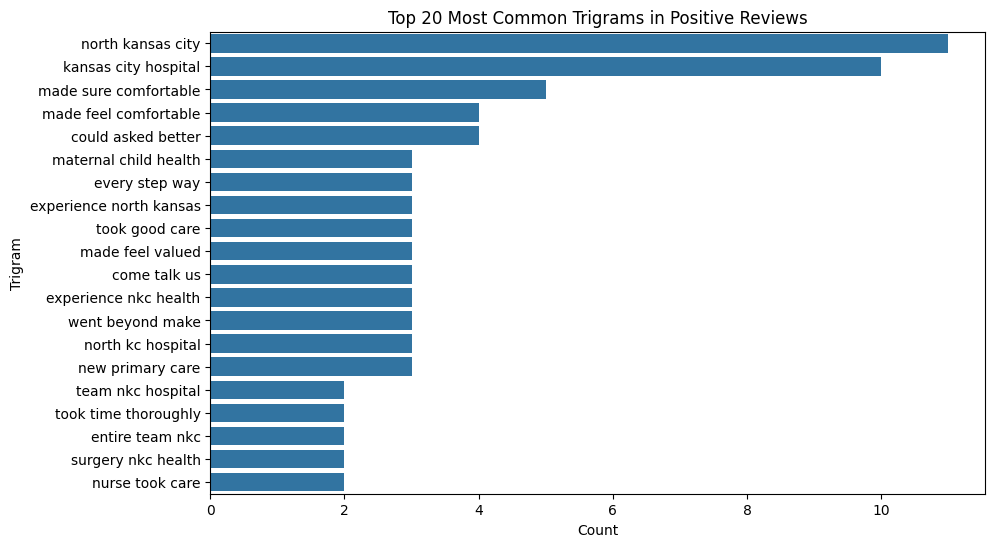

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added numpy import
from nltk.sentiment import SentimentIntensityAnalyzer # Added SentimentIntensityAnalyzer import

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('vader_lexicon', quiet=True) # Added VADER lexicon download

# Define the path to your reviews.csv file (assuming it's already set in 'path')
path = "Your/data"
reviews = pd.read_csv(path + '/reviews.csv')

# Initialize VADER sentiment analyzer if not already done
sid = SentimentIntensityAnalyzer()

# Function to compute sentiment scores (copied from previous cell for self-containment)
def sentiment(review):
  if(type(review) != str):
    return [np.nan, np.nan, np.nan, np.nan]
  sentiment_score = sid.polarity_scores(review)
  return [
      sentiment_score['neg'],
      sentiment_score['neu'],
      sentiment_score['pos'],
      sentiment_score['compound']
  ]

# Add sentiment metrics to the dataset (if not already present)
if 'sentiment_compound' not in reviews.columns:
    reviews[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = \
    reviews['snippet'].apply(sentiment).apply(pd.Series)

# Function to categorize sentiment_compound scores
def get_vader_label(compound_score):
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply the function to create the 'vader_label' column
reviews['vader_label'] = reviews['sentiment_compound'].apply(get_vader_label)

# Filter for positive reviews
positive_reviews = reviews[reviews['vader_label'] == 'positive'].copy()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\\W', ' ', text) # Remove non-word characters
    text = re.sub(r'\\s+', ' ', text) # Replace multiple spaces with a single space
    return text

positive_reviews['cleaned_snippet'] = positive_reviews['snippet'].apply(clean_text)

stop_words = set(stopwords.words('english'))

def generate_ngrams(text, n):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return list(ngrams(tokens, n))

# Bigrams for positive reviews
pos_bigrams_list = []
for text in positive_reviews['cleaned_snippet']:
    pos_bigrams_list.extend(generate_ngrams(text, 2))

pos_bigram_counts = Counter(pos_bigrams_list)
top_pos_bigrams = pd.DataFrame(pos_bigram_counts.most_common(20), columns=['Bigram', 'Count'])
top_pos_bigrams['Bigram'] = top_pos_bigrams['Bigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Bigrams in Positive Reviews:")
print(top_pos_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Bigram', data=top_pos_bigrams)
plt.title('Top 20 Most Common Bigrams in Positive Reviews')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

# Trigrams for positive reviews
pos_trigrams_list = []
for text in positive_reviews['cleaned_snippet']:
    pos_trigrams_list.extend(generate_ngrams(text, 3))

pos_trigram_counts = Counter(pos_trigrams_list)
top_pos_trigrams = pd.DataFrame(pos_trigram_counts.most_common(20), columns=['Trigram', 'Count'])
top_pos_trigrams['Trigram'] = top_pos_trigrams['Trigram'].apply(lambda x: ' '.join(x))

print("\nTop 20 Trigrams in Positive Reviews:")
print(top_pos_trigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Trigram', data=top_pos_trigrams)
plt.title('Top 20 Most Common Trigrams in Positive Reviews')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()